# Keyword Berita
**Keyword berita** adalah istilah atau frasa penting yang menggambarkan isi atau topik utama dari sebuah berita. Dalam konteks jurnalisme dan penyampaian informasi, keyword berfungsi untuk:

### 1. **Mengidentifikasi Topik Utama**
   - Keyword membantu dalam mengidentifikasi tema sentral dari sebuah artikel berita. Misalnya, dalam berita tentang pemilihan umum, keyword bisa termasuk "pemilu", "calon", "partai politik", dan "suara".

### 2. **Mempermudah Pencarian**
   - Penggunaan keyword yang tepat memudahkan pencarian berita dalam mesin pencari atau database. Ketika orang mencari informasi tertentu, mereka biasanya menggunakan keyword yang relevan. Misalnya, mencari berita tentang "cuaca buruk" akan memunculkan artikel yang menggunakan keyword tersebut.

### 3. **Optimasi Mesin Pencari (SEO)**
   - Dalam konteks digital, keyword yang relevan sangat penting untuk optimasi mesin pencari (SEO). Penggunaan keyword yang strategis dalam judul dan konten berita dapat meningkatkan visibilitas artikel di hasil pencarian, menarik lebih banyak pembaca.

### 4. **Meningkatkan Relevansi**
   - Keyword membantu dalam menentukan relevansi berita terhadap isu-isu terkini. Penggunaan keyword yang sesuai dengan tren dan peristiwa terkini dapat membuat artikel lebih relevan bagi audiens.

### 5. **Pengorganisasian Konten**
   - Dalam platform berita dan media, keyword digunakan untuk mengorganisasikan dan mengkategorikan konten. Ini membantu pembaca untuk menemukan berita terkait dengan topik yang sama dengan lebih mudah.

### 6. **Analisis dan Riset**
   - Dalam analisis data berita, keyword dapat digunakan untuk melakukan analisis tren, melihat topik-topik yang sedang hangat diperbincangkan, serta membantu dalam riset yang lebih mendalam tentang isu tertentu.

### Kesimpulan
Keyword berita merupakan elemen krusial dalam penyampaian informasi. Mereka bukan hanya membantu dalam identifikasi dan pencarian berita, tetapi juga berperan dalam strategi penyebaran informasi, optimasi SEO, dan analisis tren berita. Penggunaan keyword yang tepat dapat meningkatkan keterbacaan dan dampak dari sebuah artikel berita.

In [1]:
# Library untuk text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

# Library untuk data manipulation
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

# Library untuk text similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
data = pd.read_csv('hasil_crowling.csv')
data.head()

,Judul,Tanggal,Ringkasan,Kategori
0,"Viral Sopir Truk Nekat Lawan Arah di Jakut, Po...",16 Okt 2024 18:04,Dalam rekaman yang diunggah terlihat sopir tru...,Peristiwa
1,Polisi Pastikan 2 Tersangka Pencabulan di Pant...,16 Okt 2024 18:02,"Kabid Humas Polda Metro Jaya, Kombes Pol Ade A...",Peristiwa
2,Sejumlah Tokoh dan Pakar Siap Sukseskan Pelant...,16 Okt 2024 16:05,Mulusnya transisi pemerintahan dapat menjaga s...,Politik
3,"Kasus Emas Antam, Saksi Sebut Budi Said Lakuka...",16 Okt 2024 16:01,"Mantan Manajer Retail PT Antam, Nuning Septi W...",Peristiwa
4,5 Fakta Terkait Budi Gunawan Diberhentikan dar...,16 Okt 2024 16:00,Dewan Perwakilan Rakyat (DPR) RI telah menerim...,Peristiwa


#Prepocessing
- membersihkan dan menghapus tanda baca yang ada.

In [3]:
def clean_text(text):
	text = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))', ' ', text) # Menghapus https* and www*
	text = re.sub(r'@[^\s]+', ' ', text) # Menghapus username
	text = re.sub(r'[\s]+', ' ', text) # Menghapus tambahan spasi
	text = re.sub(r'#([^\s]+)', ' ', text) # Menghapus hashtags
	text = re.sub(r"[^a-zA-Z :\.]", "", text) # Menghapus tanda baca
	text = re.sub(r'\d', ' ', text) # Menghapus angka
	text = text.lower()
	text = text.encode('ascii','ignore').decode('utf-8') #Menghapus ASCII dan unicode
	text = re.sub(r'[^\x00-\x7f]',r'', text)
	text = text.replace('\n','') #Menghapus baris baru
	text = text.strip()
	return text

def clean_stopword(tokens):
	listStopword =  set(stopwords.words('indonesian'))
	filtered_words = [word for word in tokens if word.lower() not in listStopword]
	return filtered_words

In [4]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
def preprocess_text(content):
	result = {}
	for i, text in enumerate(tqdm(content)):
		cleaned_text = clean_text(text)
		tokens = word_tokenize(cleaned_text)
		cleaned_stopword = clean_stopword(tokens)
		result[i] = ' '.join(cleaned_stopword)
	return result

prep_result = preprocess_text(data['Ringkasan'])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
100%|██████████| 53/53 [00:00<00:00, 1193.75it/s]


In [12]:
print(prep_result[39])

operasi zebra jaya rangka pengamanan jelang pelantikan presiden wapres terpilih prabowo subiantogibran rakabuming raka oktober . operasi wilayah hukum polda metro jaya oktober .


In [13]:
kalimat_preprocessing = nltk.sent_tokenize(prep_result[39])
kalimat = nltk.sent_tokenize(data['Ringkasan'][39])

In [14]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_preprocessing = tfidf_vectorizer.fit_transform(kalimat_preprocessing)

terms = tfidf_vectorizer.get_feature_names_out()
tfidf_preprocessing = pd.DataFrame(data=tfidf_preprocessing.toarray(), columns=terms)

tfidf_preprocessing

,hukum,jaya,jelang,metro,oktober,operasi,pelantikan,pengamanan,polda,prabowo,presiden,raka,rakabuming,rangka,subiantogibran,terpilih,wapres,wilayah,zebra
0,0.000000,0.193514,0.271977,0.000000,0.193514,0.193514,0.271977,0.271977,0.000000,0.271977,0.271977,0.271977,0.271977,0.271977,0.271977,0.271977,0.271977,0.000000,0.271977
1,0.425677,0.302873,0.000000,0.425677,0.302873,0.302873,0.000000,0.000000,0.425677,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.425677,0.000000


In [15]:
cossim_prep = cosine_similarity(tfidf_preprocessing, tfidf_preprocessing)

similarity_matrix = pd.DataFrame(cossim_prep,
								 index=range(len(kalimat_preprocessing)),
								 columns=range(len(kalimat_preprocessing)))

similarity_matrix


,0,1
0,1.00000,0.17583
1,0.17583,1.00000


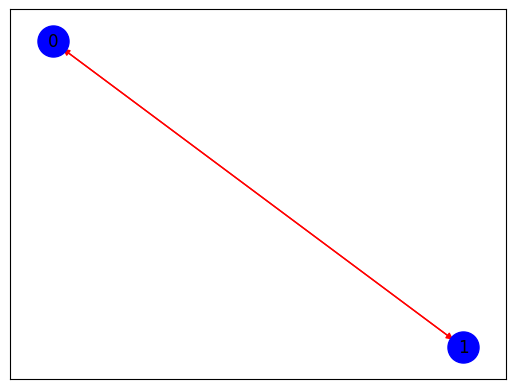

In [16]:
G_preprocessing = nx.DiGraph()
for i in range(len(cossim_prep)):
    G_preprocessing.add_node(i)

for i in range(len(cossim_prep)):
    for j in range(len(cossim_prep)):
        similarity_preprocessing = cossim_prep[i][j]
        if similarity_preprocessing > 0.1 and i != j:
            G_preprocessing.add_edge(i, j)

pos = nx.spring_layout(G_preprocessing, k=2)
nx.draw_networkx_nodes(G_preprocessing, pos, node_size=500, node_color='b')
nx.draw_networkx_edges(G_preprocessing, pos, edge_color='red', arrows=True)
nx.draw_networkx_labels(G_preprocessing, pos)

plt.show()

In [17]:
closeness_preprocessing = nx.closeness_centrality(G_preprocessing)

sorted_closeness_preprocessing = sorted(closeness_preprocessing.items(), key=lambda x: x[1], reverse=True)
print("Closeness Centrality:")
for node, closeness in sorted_closeness_preprocessing:
    print(f"Node {node}: {closeness:.4f}")

Closeness Centrality:
Node 0: 1.0000
Node 1: 1.0000


In [18]:
ringkasan_closeness_preprocessing = ""
print("Tiga Node Tertinggi Closeness Centrality Menggunakan Preprocessing:")
for node, closeness_preprocessing in sorted_closeness_preprocessing[:3]:
    top_sentence = kalimat[node]
    ringkasan_closeness_preprocessing += top_sentence + " "
    print(f"Node {node}: Closeness Centrality = {closeness_preprocessing:.4f}")
    print(f"Kalimat: {top_sentence}\n")

Tiga Node Tertinggi Closeness Centrality Menggunakan Preprocessing:
Node 0: Closeness Centrality = 1.0000
Kalimat: Operasi Zebra Jaya dilakukan dalam rangka pengamanan jelang pelantikan Presiden dan Wapres terpilih Prabowo Subianto-Gibran Rakabuming Raka pada 20 Oktober 2024 mendatang.

Node 1: Closeness Centrality = 1.0000
Kalimat: Adapun operasi ini akan berlangsung di wilayah hukum Polda Metro Jaya pada 14 hingga 27 Oktober 2024.



In [19]:
pagerank_preprocessing = nx.pagerank(G_preprocessing)

sorted_pagerank_preprocessing= sorted(pagerank_preprocessing.items(), key=lambda x: x[1], reverse=True)
print("Page Rank :")
for node, pagerank_preprocessing in sorted_pagerank_preprocessing:
    print(f"Node {node}: {pagerank_preprocessing:.4f}")

Page Rank :
Node 0: 0.5000
Node 1: 0.5000


In [20]:
ringkasan_pagerank_preprocessing = ""
print("Tiga Node Tertinggi Page Rank Menggunakan Preprocessing:")
for node, pagerank_preprocessing in sorted_pagerank_preprocessing[:3]:
    top_sentence = kalimat[node]
    ringkasan_pagerank_preprocessing += top_sentence + " "
    print(f"Node {node}: Page Rank = {pagerank_preprocessing:.4f}")
    print(f"Kalimat: {top_sentence}\n")

Tiga Node Tertinggi Page Rank Menggunakan Preprocessing:
Node 0: Page Rank = 0.5000
Kalimat: Operasi Zebra Jaya dilakukan dalam rangka pengamanan jelang pelantikan Presiden dan Wapres terpilih Prabowo Subianto-Gibran Rakabuming Raka pada 20 Oktober 2024 mendatang.

Node 1: Page Rank = 0.5000
Kalimat: Adapun operasi ini akan berlangsung di wilayah hukum Polda Metro Jaya pada 14 hingga 27 Oktober 2024.

